In [2]:
 # ── Core libraries ──────────────────────────────────────────────
import requests
import json
import re
import time
from datetime import datetime
 
# ── Data handling ────────────────────────────────────────────────
import pandas as pd
 
# ── NLP ──────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
 
# ── Web Scraping ─────────────────────────────────────────────────
from bs4 import BeautifulSoup
 
# ── Visualization ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
 
print("✅ All imports successful!")

✅ All imports successful!


In [3]:
NEWS_API_KEY = "de6d5996e1424cb9a6e7015868f7f902"
CATEGORIES = ["technology", "business"]
SEARCH_QUERIES = ["economy","artificial intelligence"]
PAGE_SIZE = 2
COUNTRY = "us"
BASE_URL = "https://newsapi.org/v2"



In [4]:
all_articles = []

In [5]:
def fetch_top_headlines(category:str, country:str=COUNTRY , page_size:int=PAGE_SIZE) -> list:
    url = f"{BASE_URL}/top-headlines"
    params = {
        "apiKey": NEWS_API_KEY,
        "category": category,
        "country": country,
        "pageSize": page_size
    }
    print (params)
    
    response = requests.get(url, params=params)    
    print (response)
    if response.status_code != 200:
        print(f"API ERROR: {response.status_code} - {response.text}")
    articles = response.json().get("articles", [])
    print(articles)
    return articles
    
for cat in CATEGORIES:
    articles = fetch_top_headlines(category=cat,country=COUNTRY)
    for art in articles:
        art["query_category"] = cat
    all_articles.extend(articles)

print(all_articles)

        


{'apiKey': 'de6d5996e1424cb9a6e7015868f7f902', 'category': 'technology', 'country': 'us', 'pageSize': 2}
<Response [200]>
[{'source': {'id': None, 'name': 'Nintendoeverything.com'}, 'author': 'Brian', 'title': 'Mario Kart World 1.6.1 update out now, patch notes - Nintendo Everything', 'description': 'Mario Kart World just received a new version 1.6.1 update from Nintendo, and you can get the patch notes here.', 'url': 'https://nintendoeverything.com/mario-kart-world-1-6-1-update-out-now-patch-notes/', 'urlToImage': 'https://nintendoeverything.com/wp-content/uploads/Mario-Kart-World-1.6.1-update.jpg', 'publishedAt': '2026-04-10T01:06:45Z', 'content': 'Nintendo is back with another update for Mario Kart World, bringing the game up to version 1.6.1.\r\nThis patch is about bug fixes, so there aren’t any new additions here. Nintendo addressed two specif… [+776 chars]'}, {'source': {'id': 'ign', 'name': 'IGN'}, 'author': None, 'title': 'Forza Horizon 6 Is Every Japanese Driving Fantasy Rolle

In [6]:
def fetch_by_keyword(query:str, country:str=COUNTRY , page_size:int=PAGE_SIZE) -> list:
    url = f"{BASE_URL}/everything"
    request = {
        "apiKey": NEWS_API_KEY,
        "q": query,
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": page_size
    }
    print (request)
    
    response = requests.get(url, params=request)    
    print (response)
    if response.status_code != 200:
        print(f"API ERROR: {response.status_code} - {response.text}")
    articles = response.json().get("articles", [])
    print(articles)
    return (articles)

for query in SEARCH_QUERIES:
    articles = fetch_by_keyword(query=query) 
    for art in articles:
        art["query_category"] = query 
    all_articles.extend(articles)
print(all_articles)


{'apiKey': 'de6d5996e1424cb9a6e7015868f7f902', 'q': 'economy', 'language': 'en', 'sortBy': 'publishedAt', 'pageSize': 2}
<Response [200]>
[{'source': {'id': 'abc-news-au', 'name': 'ABC News (AU)'}, 'author': None, 'title': 'Peter Dutton appointed to Queensland investment board', 'description': "Mr Dutton's has kept a low public profile since he led the Coalition to defeat at the 2025 federal election, and also lost his seat of Dickson.", 'url': 'https://www.abc.net.au/news/2026-04-10/peter-dutton-apointed-to-qld-investment-board/106551594', 'urlToImage': 'https://live-production.wcms.abc-cdn.net.au/b48a5c700379682abe5b28836c95f0c9?impolicy=wcms_watermark_news&cropH=2813&cropW=5000&xPos=0&yPos=0&width=862&height=485&imformat=generic', 'publishedAt': '2026-04-10T04:31:17Z', 'content': "Former opposition leader Peter Dutton has been appointed to the board of the Queensland Investment Corporation by the state's LNP government.\r\nMr Dutton has kept a low profile since leading the Coali… [+

In [7]:
for art in all_articles:
    print(art)
    

{'source': {'id': None, 'name': 'Nintendoeverything.com'}, 'author': 'Brian', 'title': 'Mario Kart World 1.6.1 update out now, patch notes - Nintendo Everything', 'description': 'Mario Kart World just received a new version 1.6.1 update from Nintendo, and you can get the patch notes here.', 'url': 'https://nintendoeverything.com/mario-kart-world-1-6-1-update-out-now-patch-notes/', 'urlToImage': 'https://nintendoeverything.com/wp-content/uploads/Mario-Kart-World-1.6.1-update.jpg', 'publishedAt': '2026-04-10T01:06:45Z', 'content': 'Nintendo is back with another update for Mario Kart World, bringing the game up to version 1.6.1.\r\nThis patch is about bug fixes, so there aren’t any new additions here. Nintendo addressed two specif… [+776 chars]', 'query_category': 'technology'}
{'source': {'id': 'ign', 'name': 'IGN'}, 'author': None, 'title': 'Forza Horizon 6 Is Every Japanese Driving Fantasy Rolled into One: Hands-On Preview - IGN', 'description': None, 'url': 'https://www.ign.com/articl

In [8]:
print(json.dumps(all_articles, indent=2))

[
  {
    "source": {
      "id": null,
      "name": "Nintendoeverything.com"
    },
    "author": "Brian",
    "title": "Mario Kart World 1.6.1 update out now, patch notes - Nintendo Everything",
    "description": "Mario Kart World just received a new version 1.6.1 update from Nintendo, and you can get the patch notes here.",
    "url": "https://nintendoeverything.com/mario-kart-world-1-6-1-update-out-now-patch-notes/",
    "urlToImage": "https://nintendoeverything.com/wp-content/uploads/Mario-Kart-World-1.6.1-update.jpg",
    "publishedAt": "2026-04-10T01:06:45Z",
    "content": "Nintendo is back with another update for Mario Kart World, bringing the game up to version 1.6.1.\r\nThis patch is about bug fixes, so there aren\u2019t any new additions here. Nintendo addressed two specif\u2026 [+776 chars]",
    "query_category": "technology"
  },
  {
    "source": {
      "id": "ign",
      "name": "IGN"
    },
    "author": null,
    "title": "Forza Horizon 6 Is Every Japanese Driving

In [9]:
def articles_to_dataframe(articles:list) -> pd.DataFrame:
    rows = []
    for art in articles:
        rows.append({
            "source": art.get("source", {}).get("name"),
            "author": art.get("author"),
            "title": art.get("title"),
            "description": art.get("description"),
            "url": art.get("url"),
            "publishedAt": art.get("publishedAt"),
            "content": art.get("content"),
            "query_category": art.get("query_category"),
            "full_text": f"{art.get('title', '')} {art.get('description', '')} {art.get('content', '')}"    
        })
    df = pd.DataFrame(rows) 
    return df
df = articles_to_dataframe(all_articles)
df.head()

,source,author,title,description,url,publishedAt,content,query_category,full_text
0,Nintendoeverything.com,Brian,"Mario Kart World 1.6.1 update out now, patch n...",Mario Kart World just received a new version 1...,https://nintendoeverything.com/mario-kart-worl...,2026-04-10T01:06:45Z,Nintendo is back with another update for Mario...,technology,"Mario Kart World 1.6.1 update out now, patch n..."
1,IGN,NaN,Forza Horizon 6 Is Every Japanese Driving Fant...,NaN,https://www.ign.com/articles/forza-horizon-6-i...,2026-04-10T00:23:06Z,NaN,technology,Forza Horizon 6 Is Every Japanese Driving Fant...
2,Politico,Associated Press,"USPS to suspend pension contributions, seeks 4...","If approved by regulators, the price of a firs...",https://www.politico.com/news/2026/04/09/usps-...,2026-04-10T01:00:00Z,Despite the suspension of employer contributio...,business,"USPS to suspend pension contributions, seeks 4..."
3,Wired,Maxwell Zeff,OpenAI Backs Bill That Would Limit Liability f...,The ChatGPT-maker testified in favor of an Ill...,https://www.wired.com/story/openai-backs-bill-...,2026-04-10T00:19:00Z,OpenAI is throwing its support behind an Illin...,business,OpenAI Backs Bill That Would Limit Liability f...
4,ABC News (AU),NaN,Peter Dutton appointed to Queensland investmen...,Mr Dutton's has kept a low public profile sinc...,https://www.abc.net.au/news/2026-04-10/peter-d...,2026-04-10T04:31:17Z,Former opposition leader Peter Dutton has been...,economy,Peter Dutton appointed to Queensland investmen...


In [12]:
# ── Regex patterns used in this project ─────────────────────────
PATTERNS = {
    "url":         re.compile(r'https?://\S+'),
    #before → "Read more at https://bbc.com/news/article-123 today"
    #after  → "Read more at   today"
    "html_tag":    re.compile(r'<[^>]+>'),
    #before → "<b>BREAKING:</b> Markets <em>fall</em> sharply"
    #after  → " BREAKING:  Markets  fall  sharply"
    "punctuation": re.compile(r'[^a-zA-Z\s]'),
    #before → "Apple stock up 3.4% — best day since 2021!"
    #after  → "Apple stock up      best day since      "
    "extra_space": re.compile(r'\s+'),
    #before → "Apple   stock    up      best   day"
    #after  → "Apple stock up best day"
    "ticker":      re.compile(r'\b[A-Z]{2,5}\b'),          # stock tickers / abbreviations
    #input   → "AAPL and TSLA both rose as NASA announced funding"
    #extracts → ["AAPL", "TSLA", "NASA"]
    "proper_noun": re.compile(r'\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)+'),  # naive NER
    #input    → "Elon Musk met Tim Cook in New York yesterday"
    #extracts → ["Elon Musk", "Tim Cook", "New York"]
    "year":        re.compile(r'\b(19|20)\d{2}\b'),
    #input    → "The 2024 budget follows the 2023 deficit report"
    #extracts → ["2024", "2023"]
    "number":      re.compile(r'\b\d+\.?\d*\b'),
    #input    → "Stocks fell 4.2 points and GDP grew by 1 percent"
    #extracts → ["4.2", "1"]
    "chars_bracket": re.compile(r'\[\+?\d+\s*chars?\]'),   # NewsAPI truncation marker
    #before → "The economy shrank [+247 chars]"
    #after  → "The economy shrank  "
}
 
def clean_text(text: str) -> str:
    """Full regex cleaning pipeline for NLP."""
    text = PATTERNS["html_tag"].sub(' ', text)        # remove HTML tags
    text = PATTERNS["url"].sub(' ', text)             # remove URLs
    text = PATTERNS["chars_bracket"].sub(' ', text)   # remove [+N chars] artifacts
    text = PATTERNS["punctuation"].sub(' ', text)     # remove punctuation/numbers
    text = PATTERNS["extra_space"].sub(' ', text)     # normalize whitespace
    return text.strip().lower()
 
def extract_proper_nouns(text: str) -> list:
    """Extract likely named entities using a regex heuristic."""
    return PATTERNS["proper_noun"].findall(text)
 
 
def extract_tickers(text: str) -> list:
    """Extract stock ticker / acronym candidates."""
    return PATTERNS["ticker"].findall(text)
 
# ── Apply cleaning to the DataFrame ─────────────────────────────
df["clean_text"]    = df["full_text"].apply(clean_text)
df["proper_nouns"]  = df["full_text"].apply(extract_proper_nouns)
df["tickers"]       = df["title"].apply(extract_tickers)
 
# ── Demo: show before vs after cleaning ─────────────────────────
idx = 1
print("ORIGINAL:\n", df['full_text'].iloc[idx][:300])
print("\nCLEANED:\n",  df['clean_text'].iloc[idx][:300])
print("\nPROPER NOUNS FOUND:", df['proper_nouns'].iloc[idx][:5])
 

ORIGINAL:
 Forza Horizon 6 Is Every Japanese Driving Fantasy Rolled into One: Hands-On Preview - IGN None None

CLEANED:
 forza horizon is every japanese driving fantasy rolled into one hands on preview ign none none

PROPER NOUNS FOUND: ['Forza Horizon', 'Is Every Japanese Driving Fantasy Rolled', 'On Preview', 'None None']


In [14]:
stop_words = set(stopwords.words('english'))
print(stop_words)

{'what', 'few', 'in', "we're", 't', 'out', 'wouldn', "i'm", 'weren', 'this', 'being', "mightn't", 'themselves', "couldn't", 'we', 'y', "won't", 'he', 'will', 'any', "i've", "haven't", 'which', 'when', 've', 'if', 'd', 'each', 'most', 'into', 'above', 'herself', 'our', "don't", "it'd", "it's", "she'd", 'just', 'him', "doesn't", "you'll", 'theirs', 'through', 'or', 'than', "he'll", 'how', "shouldn't", 'o', 'there', "hasn't", 'own', "we'll", 'only', 'his', 'hadn', 'has', "didn't", 's', 'ours', "we'd", "it'll", 'under', 'to', 'itself', 'but', 'no', 'yourselves', 'were', 'shouldn', "isn't", 'i', 'myself', 'of', 'then', 'them', 'below', 'are', 'll', "they'll", 'been', 'ma', 'between', 'does', 'all', "he's", 'mightn', 'an', 'doesn', 'am', 'hers', 'isn', 'the', 'ourselves', 'same', 'why', 'its', 'as', 'himself', "hadn't", 'my', 'now', 'a', "you're", 'during', 'yours', 'further', 'shan', 'did', 'too', 'who', 'here', 'have', 'they', 'didn', 'having', "i'll", 'over', 'where', "she's", 'their', "w

In [15]:
STOP_WORDS = set(stopwords.words('english'))
# Add domain-specific stopwords
STOP_WORDS.update(['said', 'say', 'says', 'new', 'us', 'also', 'one', 'two',
                   'would', 'could', 'may', 'will', 'get', 'got', 'year',
                   'first', 'last', 'week', 'day', 'time', 'report'])
print(STOP_WORDS)

{'two', 'what', 'few', 'in', "we're", 't', 'out', 'wouldn', "i'm", 'weren', 'this', 'being', "mightn't", 'themselves', "couldn't", 'we', 'last', 'y', "won't", 'he', 'will', 'any', "i've", 'new', "haven't", 'which', 'when', 've', 'if', 'd', 'each', 'most', 'say', 'into', 'above', 'herself', 'our', "don't", "it'd", "it's", "she'd", 'may', 'just', 'him', "doesn't", "you'll", 'theirs', 'through', 'or', 'than', "he'll", 'how', "shouldn't", 'report', 'o', 'there', "hasn't", 'first', 'own', "we'll", 'only', 'get', 'his', 'hadn', 'has', "didn't", 's', 'ours', 'week', "we'd", "it'll", 'under', 'to', 'would', 'itself', 'but', 'no', 'also', 'yourselves', 'were', 'shouldn', "isn't", 'i', 'myself', 'of', 'then', 'them', 'below', 'are', 'll', "they'll", 'been', 'ma', 'between', 'does', 'all', "he's", 'mightn', 'an', 'doesn', 'am', 'one', 'hers', 'isn', 'the', 'ourselves', 'same', 'why', 'its', 'as', 'himself', "hadn't", 'my', 'now', 'a', "you're", 'could', 'during', 'yours', 'further', 'shan', 'did'

In [16]:
tokens = word_tokenize('chinese startup shengshu raises million to chinese')
print(tokens)
 

['chinese', 'startup', 'shengshu', 'raises', 'million', 'to', 'chinese']


In [23]:
def tokenize_and_filter(text: str) -> list:
    """Tokenize text and remove stopwords & short tokens."""
    tokens = word_tokenize(text)                            # split into words
    tokens = [t for t in tokens if t.isalpha()]            # keep only alphabetic
    tokens = [t for t in tokens if t not in STOP_WORDS]    # remove stopwords
    tokens = [t for t in tokens if len(t) > 2]             # remove very short words
    return tokens
 
 
# Apply to all articles
df["tokens"] = df["clean_text"].apply(tokenize_and_filter)
df["token_count"] = df["tokens"].apply(len)
df.head()

,source,author,title,description,url,publishedAt,content,query_category,full_text,clean_text,proper_nouns,tickers,tokens,token_count
0,Nintendoeverything.com,Brian,"Mario Kart World 1.6.1 update out now, patch n...",Mario Kart World just received a new version 1...,https://nintendoeverything.com/mario-kart-worl...,2026-04-10T01:06:45Z,Nintendo is back with another update for Mario...,technology,"Mario Kart World 1.6.1 update out now, patch n...",mario kart world update out now patch notes ni...,"[Mario Kart World, Nintendo Everything Mario K...",[],"[mario, kart, world, update, patch, notes, nin...",34
1,IGN,NaN,Forza Horizon 6 Is Every Japanese Driving Fant...,NaN,https://www.ign.com/articles/forza-horizon-6-i...,2026-04-10T00:23:06Z,NaN,technology,Forza Horizon 6 Is Every Japanese Driving Fant...,forza horizon is every japanese driving fantas...,"[Forza Horizon, Is Every Japanese Driving Fant...",[IGN],"[forza, horizon, every, japanese, driving, fan...",12
2,Politico,Associated Press,"USPS to suspend pension contributions, seeks 4...","If approved by regulators, the price of a firs...",https://www.politico.com/news/2026/04/09/usps-...,2026-04-10T01:00:00Z,Despite the suspension of employer contributio...,business,"USPS to suspend pension contributions, seeks 4...",usps to suspend pension contributions seeks ce...,"[Politico If, Postal Service]",[USPS],"[usps, suspend, pension, contributions, seeks,...",37
3,Wired,Maxwell Zeff,OpenAI Backs Bill That Would Limit Liability f...,The ChatGPT-maker testified in favor of an Ill...,https://www.wired.com/story/openai-backs-bill-...,2026-04-10T00:19:00Z,OpenAI is throwing its support behind an Illin...,business,OpenAI Backs Bill That Would Limit Liability f...,openai backs bill that would limit liability f...,"[Backs Bill That Would Limit Liability, Enable...","[AI, WIRED]","[openai, backs, bill, limit, liability, enable...",47
4,ABC News (AU),NaN,Peter Dutton appointed to Queensland investmen...,Mr Dutton's has kept a low public profile sinc...,https://www.abc.net.au/news/2026-04-10/peter-d...,2026-04-10T04:31:17Z,Former opposition leader Peter Dutton has been...,economy,Peter Dutton appointed to Queensland investmen...,peter dutton appointed to queensland investmen...,"[Peter Dutton, Mr Dutton, Peter Dutton, Queens...",[],"[peter, dutton, appointed, queensland, investm...",40


In [19]:
# ── Global word frequency across ALL articles ────────────────────
all_tokens = [token for tokens in df["tokens"] for token in tokens]
freq_dist  = FreqDist(all_tokens)
 
print(f"Total tokens (after cleaning): {len(all_tokens):,}")
print(f"Unique tokens: {len(freq_dist):,}")
print("\nTop 20 most frequent words:")
for word, count in freq_dist.most_common(20):
    print(f"  {word:20s} {count:4d}")

Total tokens (after cleaning): 316
Unique tokens: 210

Top 20 most frequent words:
  risk                    5
  nintendo                4
  dutton                  4
  global                  4
  mario                   3
  kart                    3
  world                   3
  update                  3
  patch                   3
  bill                    3
  investment              3
  irish                   3
  hedge                   3
  funds                   3
  pose                    3
  central                 3
  bank                    3
  copa                    3
  libertadores            3
  market                  3


In [21]:
top_words = freq_dist.most_common(20)
print(top_words)

[('risk', 5), ('nintendo', 4), ('dutton', 4), ('global', 4), ('mario', 3), ('kart', 3), ('world', 3), ('update', 3), ('patch', 3), ('bill', 3), ('investment', 3), ('irish', 3), ('hedge', 3), ('funds', 3), ('pose', 3), ('central', 3), ('bank', 3), ('copa', 3), ('libertadores', 3), ('market', 3)]


In [22]:
top_words = freq_dist.most_common(20)
words, counts = zip(*top_words)
print(words)
print(counts)   

('risk', 'nintendo', 'dutton', 'global', 'mario', 'kart', 'world', 'update', 'patch', 'bill', 'investment', 'irish', 'hedge', 'funds', 'pose', 'central', 'bank', 'copa', 'libertadores', 'market')
(5, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3)


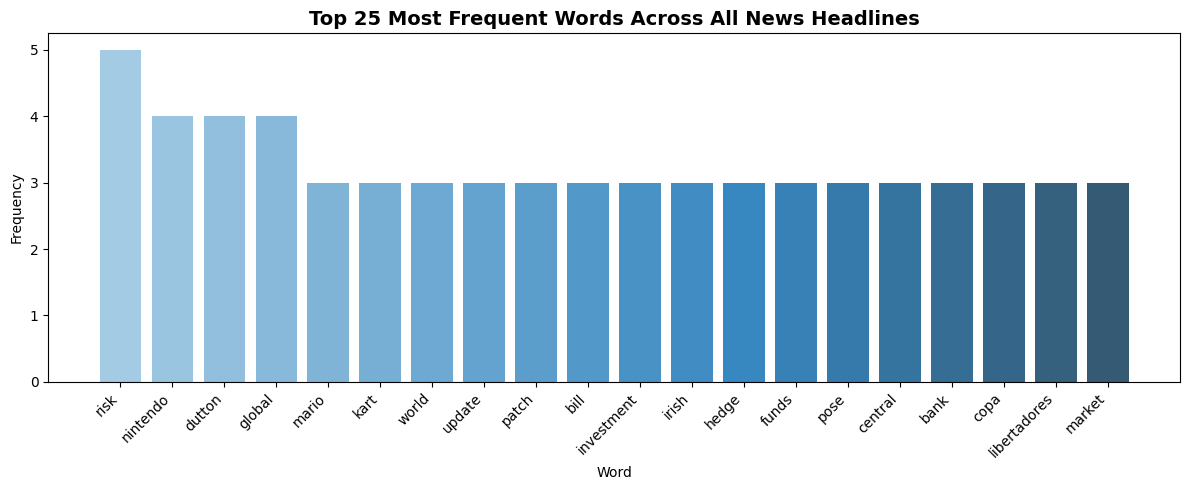

✅ Frequency chart displayed


In [24]:
 
plt.figure(figsize=(12, 5))
bars = plt.bar(words, counts, color=sns.color_palette("Blues_d", 25))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title("Top 25 Most Frequent Words Across All News Headlines", fontsize=14, fontweight='bold')
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("✅ Frequency chart displayed")
 

In [26]:
text_for_cloud = " ".join(all_tokens)
print(text_for_cloud)

mario kart world update patch notes nintendo everything mario kart world received version update nintendo patch notes nintendo back another update mario kart world bringing game version patch bug fixes additions nintendo addressed specif forza horizon every japanese driving fantasy rolled hands preview ign none none usps suspend pension contributions seeks cent stamp price hike politico approved regulators price class mail forever stamp rise cents cents despite suspension employer contributions effective friday current future retirees immediately impacted grossman risk postal service american publi openai backs bill limit liability enabled mass deaths financial disasters wired chatgpt maker testified favor illinois bill limit labs held liable even cases products cause critical harm openai throwing support behind illinois state bill shield labs liability cases models used cause serious societal harms death serious injur peter dutton appointed queensland investment board dutton kept low 

('risk', 'nintendo', 'dutton', 'global', 'mario', 'kart', 'world', 'update', 'patch', 'bill', 'investment', 'irish', 'hedge', 'funds', 'pose', 'central', 'bank', 'copa', 'libertadores', 'market', 'japan', 'private', 'credit', 'notes', 'version') (5, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2)


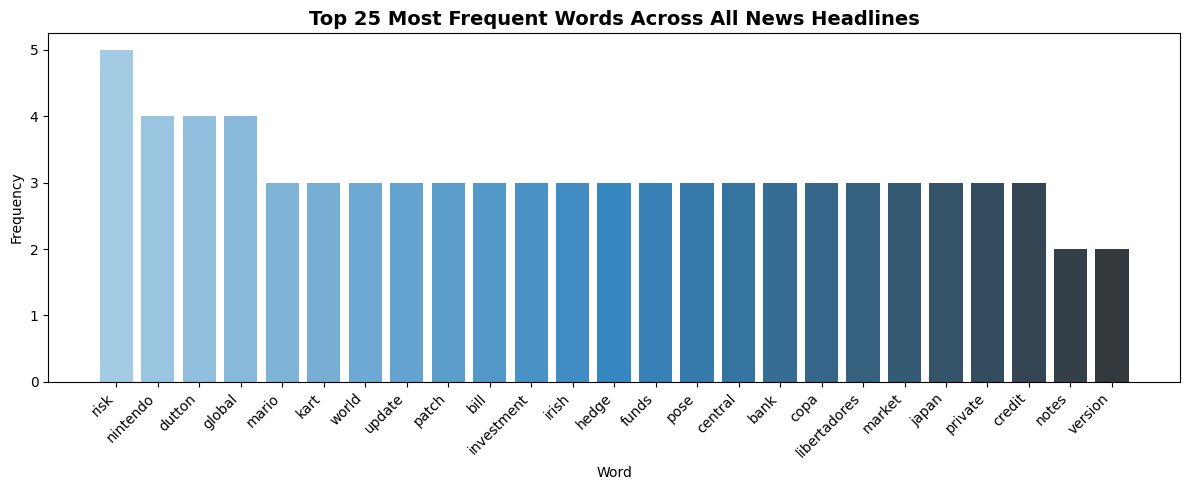

✅ Frequency chart displayed


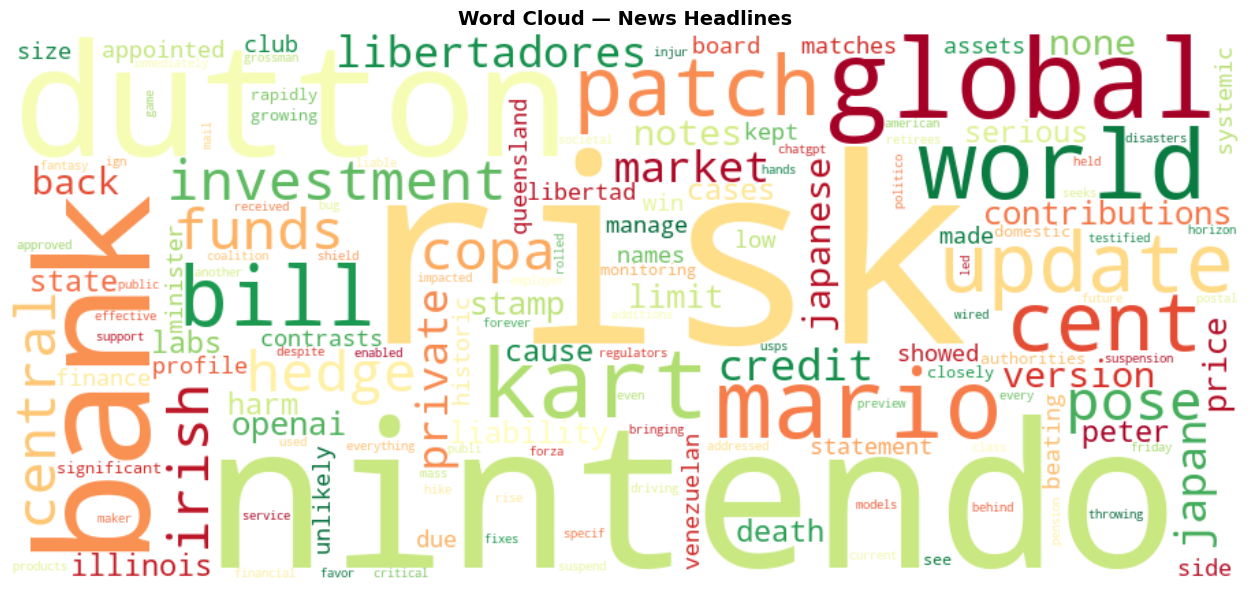

✅ Word cloud displayed


In [28]:
top_words = freq_dist.most_common(25)
words, counts = zip(*top_words)
print(words, counts)
 
plt.figure(figsize=(12, 5))
bars = plt.bar(words, counts, color=sns.color_palette("Blues_d", 25))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title("Top 25 Most Frequent Words Across All News Headlines", fontsize=14, fontweight='bold')
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("✅ Frequency chart displayed")
 
wc = WordCloud(
    width=900, height=400,
    background_color='white',
    colormap='RdYlGn',
    max_words=150,
    collocations=False
).generate(text_for_cloud)
 
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — News Headlines", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Word cloud displayed")
 

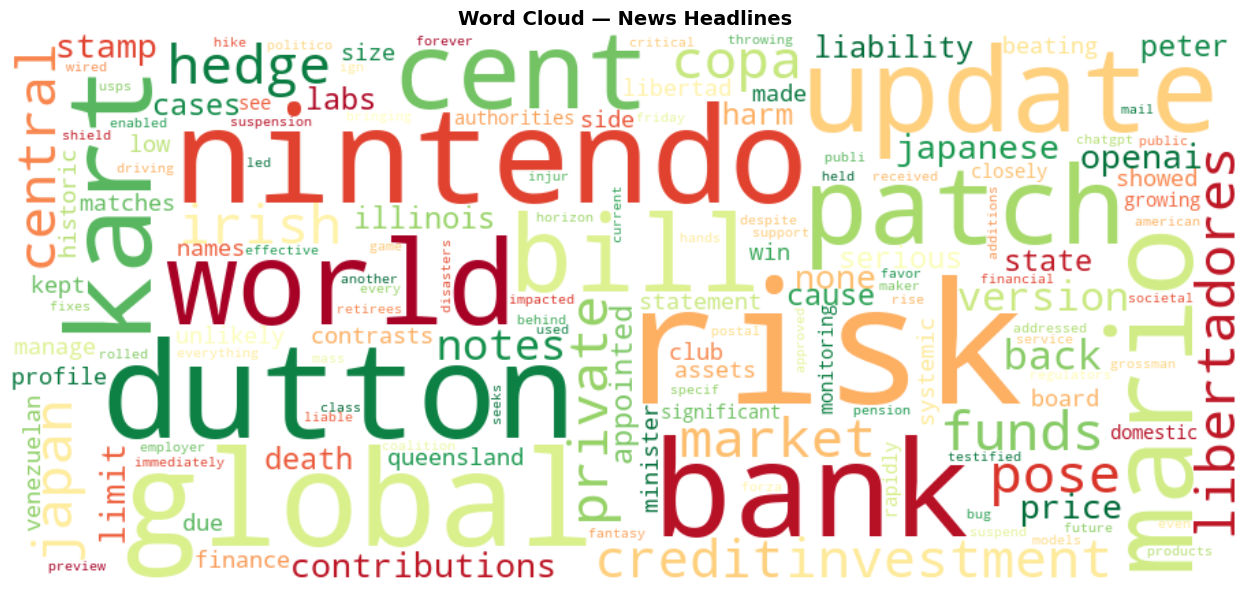

✅ Word cloud displayed


In [27]:
wc = WordCloud(
    width=900, height=400,
    background_color='white',
    colormap='RdYlGn',
    max_words=150,
    collocations=False
).generate(text_for_cloud)
 
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — News Headlines", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Word cloud displayed")